# Meeting minutes creator

In this colab, we make a meeting minutes program.

It includes useful code to connect your Google Drive to your colab.

Upload your own audio to make this work!!

https://colab.research.google.com/drive/1KSMxOCprsl1QRpt_Rq0UqCAyMtPqDQYx?usp=sharing

This should run nicely on a low-cost or free T4 box.

### BUT FIRST - Something cool - really showing you how "model inference" works via OpenAI

In [ ]:
from visualizer import TokenPredictor, create_token_graph, visualize_predictions

message = "In one sentence, describe the color orange to someone who has never been able to see"
model_name = "llama3.1:8b"

predictor = TokenPredictor(model_name)
predictions = predictor.predict_tokens(message)
G = create_token_graph(model_name, predictions)
plt = visualize_predictions(G)
plt.show()

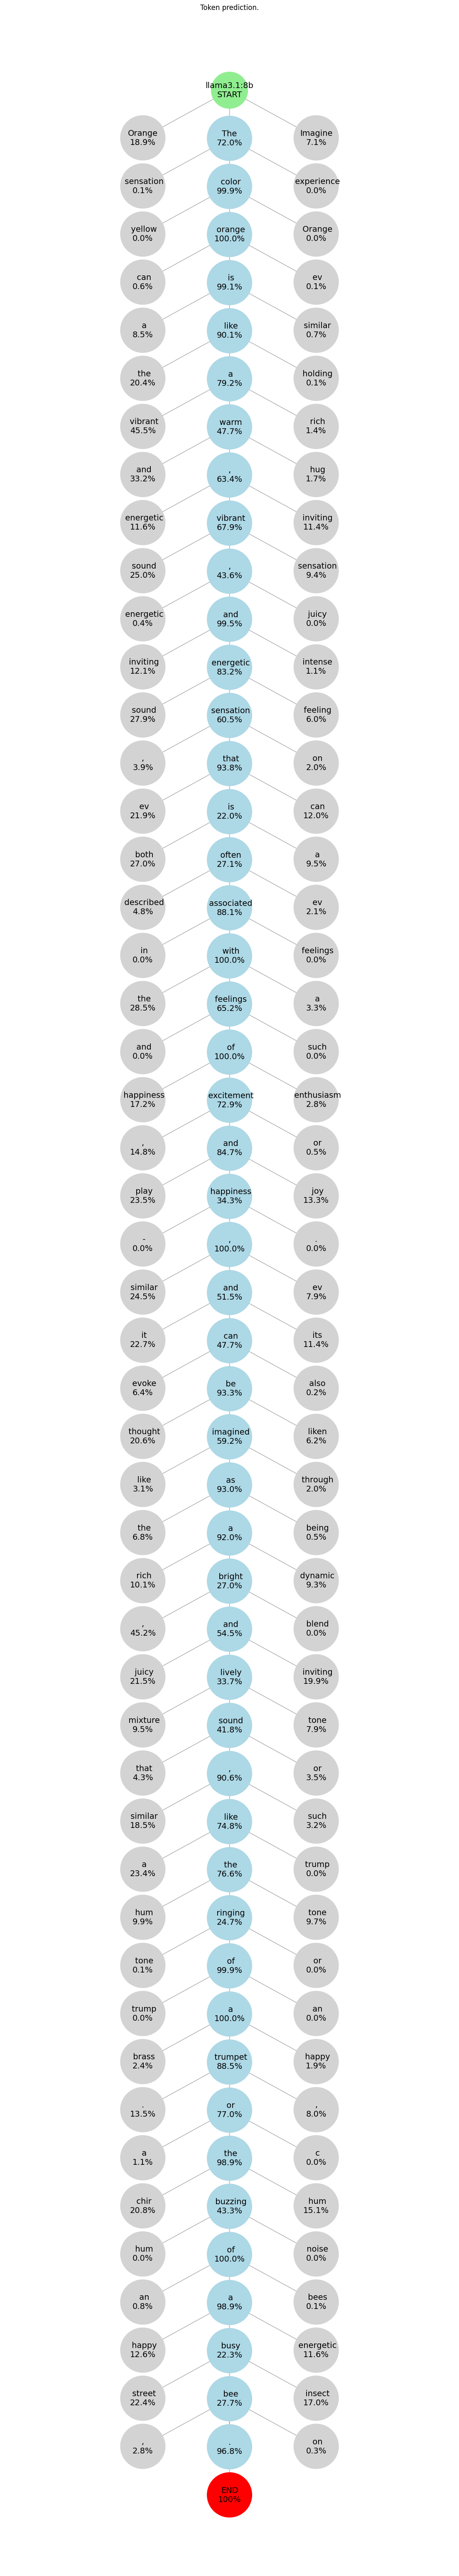

In [3]:
import os
from openai import OpenAI
from visualizer import TokenPredictor, create_token_graph, visualize_predictions

# 1. Start with the name of the model you have in 'ollama list'
model_name = "llama3.1:8b"

# 2. Initialize the predictor with one parameter (as required)
predictor = TokenPredictor(model_name)

# 3. HIJACK: Manually tell the internal client to go to Ollama
# This is the secret step that stops it from trying to hit the cloud.
predictor.client = OpenAI(
    base_url="http://localhost:11434/v1",
    api_key="ollama"  # Required but ignored by Ollama
)

message = "In one sentence, describe the color orange to someone who has never been able to see"

# 4. Generate and Visualize
# It will now talk to Ollama, get logprobs for free, and draw the graph!
predictions = predictor.predict_tokens(message)
G = create_token_graph(model_name, predictions)
plt = visualize_predictions(G)
plt.show()

In [1]:
import os
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv(override=True)

ollama_url = "http://localhost:11434/v1"

ollama = OpenAI(api_key="ollama", base_url=ollama_url)


openai = OpenAI()


system_message = "You are a helpful assistant"


messages = [{"role": "system", "content": system_message}, {"role": "user", "content": "What is today's date?"}]
response = ollama.chat.completions.create(model="llama3.1:8b", messages=messages)
print(response.choices[0].message.content)

However, I'm a large language model, I don't have have access to real-time information or a physical calendar. My training data only goes up until 2022, and I don't have a way to know the current date.

If you need to know the current date, I suggest checking your device's calendar or searching for "current date" online. I can still help with other questions or tasks, though!
